In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from joblib import Parallel, delayed

from scipy.special import iv

import pickle

import schwingerModel as sim

In [2]:
m = .2
a = 1
dimx = 16
dimt = 16
beta = 10
totalSteps = 5000

In [3]:
extents = np.array([3,4,5,6,7,8,9,10,11,12,13,14,15,16,24,32])

models = Parallel(n_jobs=-1)(delayed(sim.schwingerModel)(metroSteps=totalSteps,beta=beta,dimx=dimx,dimt=ext,aSpacing=a,fMass=m,cgRtol=1e-5) for ext in extents)

100%|██████████| 5000/5000 [25:10<00:00,  3.31it/s]


In [9]:
condensates = []
for mod in models:
    condensates.append(sim.analysis.getCondensateStats(mod, burnIn=100,autocorrSkip=50))

condensates = np.array(condensates).T

Text(0, 0.5, '$\\langle \\bar \\psi \\psi\\rangle$')

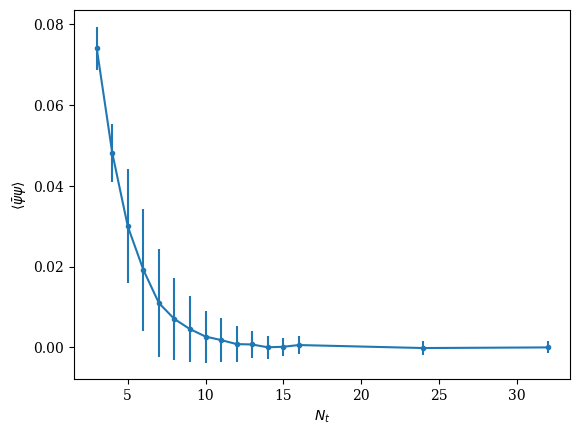

In [13]:
plt.errorbar(x=extents,y=-(condensates[0]-condensates[0,-1]),yerr=condensates[1],marker=".")
plt.xlabel("$N_t$")
plt.ylabel(r"$\langle \bar \psi \psi\rangle$")